In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## Generate Data

In [8]:
X_train = np.linspace(-1, 1, 20)

In [10]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [12]:
X_test = np.linspace(-1, 1, 20)

In [14]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

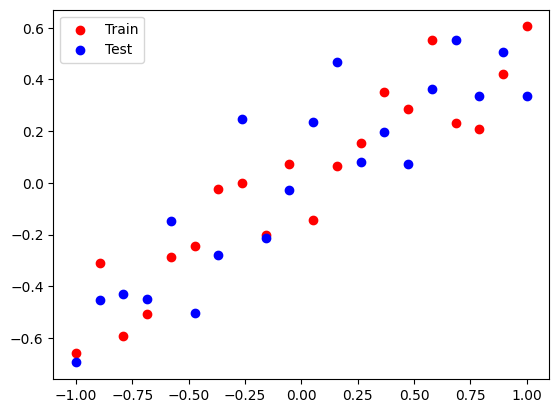

In [20]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

## Regression Model

In [27]:
model_1 = Sequential()

model_1.add(Dense(128, input_dim=1, activation='relu'))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)

model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])

history = model_1.fit(X_train, y_train, epochs=500,
                     validation_data=(X_test, y_test),
                     verbose=False)

In [29]:
# evaluate the model
_, train_mse = model_1.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.004455601330846548, Test: 0.04661782458424568


In [31]:
y_pred_1 = model_1.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [33]:
y_pred_1

array([[-0.5556226 ],
       [-0.4486823 ],
       [-0.46240008],
       [-0.46619087],
       [-0.31410766],
       [-0.16700953],
       [-0.01851901],
       [ 0.01034939],
       [-0.16429405],
       [ 0.07985494],
       [-0.11199419],
       [ 0.06965438],
       [ 0.19933076],
       [ 0.3337875 ],
       [ 0.4110716 ],
       [ 0.5146761 ],
       [ 0.29141986],
       [ 0.26334476],
       [ 0.46477723],
       [ 0.66620964]], dtype=float32)

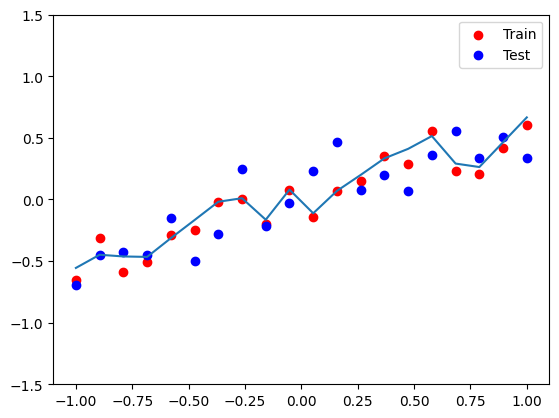

In [35]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

## Dropout Model

In [52]:
model_2 = Sequential()

model_2.add(Dense(126, input_dim=1, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(126, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(1, activation='linear'))

adam = Adam(learning_rate=0.01)

model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])

drop_out_history = model_2.fit(X_train, y_train, epochs=500,
                              validation_data= (X_test, y_test), 
                              verbose=False)

In [53]:
# evaluate the model

_, train_mse = model_2.evaluate(X_train, y_train, verbose=0)
_, test_mse = model_2.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.015208710916340351, Test: 0.034971702843904495


In [54]:
y_pred_2 = model_2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


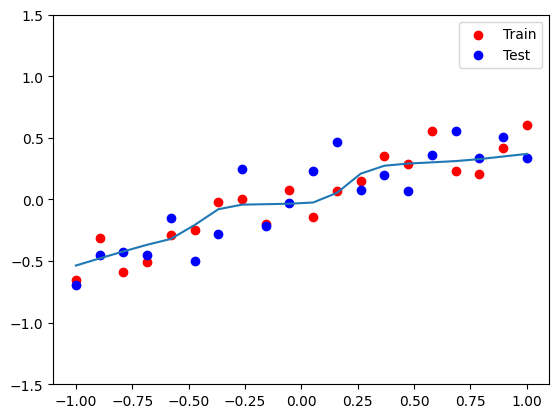

In [55]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()